# 情報システム概論　第7回

## 学習に関するテクニック
ニューラルネットワークの学習を効率的に進めるためのテクニックについて学び，認識精度を高められるようにする．

### パラメータの更新

これまでニューラルネットワークの学習について学んできましたが，ニューラルネットワークの学習の目的は，損失関数の値をできるだけ小さくする重み，バイアスといったパラメータを見つけることであった．これは最適なパラメータを見つける問題であり，そのような問題を解くことを**最適化** (optimization) という．ニューラルネットワークの最適化では，解析的に (数式を解くような方法で) 最適なパラメータを見つけることはできないため，パラメータの勾配 (微分) を使って，勾配方向にパラメータを更新するというステップを何度も繰り返す．これによって，徐々に最適なパラメータへと近づけていく．これは**確率的勾配降下法** (stochastic gradient descent) SGD と呼ばれ，パラメータ空間を闇雲に探すよりも賢い方法であった．しかし，SGDは単純な方法であり，場合によってはSGDよりも更に効率的な手法があるため，ここではこれらについて紹介する．

以前作成した，学習のためのプログラム (下記) の更新の部分がSGDによるパラメータの更新部分であるので，この部分をPythonのクラスとして下記のように実装する．

```
# データの読み込み
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 勾配
    grad = network.gradient(x_batch, t_batch)
    
    # 更新
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
  ```

In [1]:
import numpy as np

class SGD:

    """確率的勾配降下法（Stochastic Gradient Descent）"""

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

ここで，次の関数の最小値を求める問題を考える．

$$ f(x, y) = \frac{1}{20}x^2+y^2$$

これは $ f(x, y) = x^2+y^2$ がお椀のような形なので，お椀をx軸方向に伸ばしたような形状の関数である．

プログラムで表すと下記のようになる．

In [2]:
def f(x, y):
    return x**2 / 20.0 + y**2

この関数を等高線で描画すると下記のように楕円のお椀のような形になる．

Text(0, 0.5, 'y')

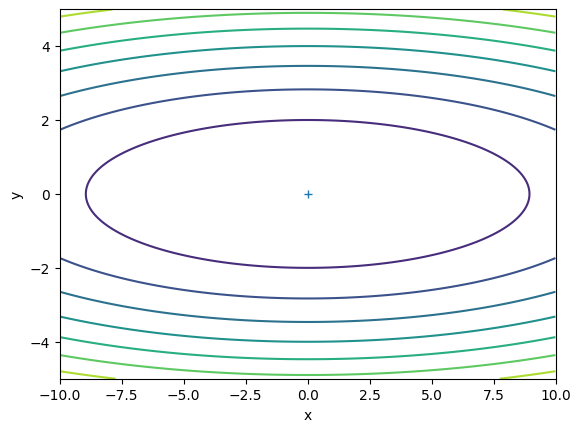

In [3]:
import matplotlib.pyplot as plt

x = np.arange(-10, 10, 0.01)
y = np.arange(-5, 5, 0.01)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# plot
plt.contour(X, Y, Z)
plt.ylim(-5, 5)
plt.xlim(-10, 10)
plt.plot(0, 0, '+')

plt.xlabel("x")
plt.ylabel("y")

$f(x, y)$ の勾配である $(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y})$ を出力する関数も作っておく．

In [4]:
def df(x, y):
    return x / 10.0, 2.0*y

ここまで準備すると，先程作ったSGDのクラスを使って，最小値を求めて，その過程を可視化する．まず，最適化を行いつつ，最適化の過程を描画する関数を作っておく．なお，探索の開始場所は $(x, y) = (-7.0, 2.0)$ としておく．

In [5]:
def draw_optimization(optimizer):
  init_pos = (-7.0, 2.0)
  params = {}
  params['x'], params['y'] = init_pos[0], init_pos[1]
  grads = {}
  grads['x'], grads['y'] = 0, 0

  x_history = []
  y_history = []

  for i in range(30):
      x_history.append(params['x'])
      y_history.append(params['y'])

      grads['x'], grads['y'] = df(params['x'], params['y'])
      optimizer.update(params, grads)

  x = np.arange(-10, 10, 0.01)
  y = np.arange(-5, 5, 0.01)

  X, Y = np.meshgrid(x, y)
  Z = f(X, Y)

  # for simple contour line
  mask = Z > 7
  Z[mask] = 0

  # plot
  plt.plot(x_history, y_history, 'o-', color="red")
  plt.contour(X, Y, Z)
  plt.ylim(-10, 10)
  plt.xlim(-10, 10)
  plt.plot(0, 0, '+')

  plt.xlabel("x")
  plt.ylabel("y")


上記の関数を使って，SGDを用いた最適化をして，その過程を描画する．

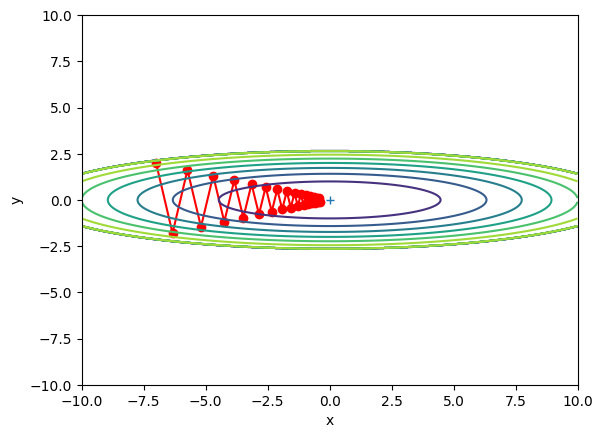

In [6]:
sgd = SGD(lr=0.95)

draw_optimization(sgd)

SGDによる最適化の過程を確認すると，ジグザグな動きをしており，これはかなり非効率な経路に見える．つまり，SGDの欠点は，関数の形状が等方的でない，つまり伸びた形の関数だと非効率な経路で探索することになる点である．この原因は勾配の方向が本来の最小値ではない方向を指していることである．

### Momentum
モーメンタム(Momentum) とは「運動量」という意味の言葉で，物理に関係がある．Momentumという手法は数式で次のように表される．
$$
\mathbf v \leftarrow \alpha \mathbf v - \eta \frac{\partial L}{\partial \mathbf W} \\
\mathbf W \leftarrow \mathbf W + \mathbf v
$$
$\mathbf W$ は更新する重みパラメータ，$\frac{\partial L}{\partial \mathbf W}$は$\mathbf W$に関する損失関数の勾配，$\eta$ (イータ) は学習係数を表す．ここでは，新たに$\mathbf v$ という変数が登場するが，これは物理でいうところの「速度」に対応する．上記の式では，物体が勾配方向に力を受け，その力によって物体の速度が加算されるという物理法則を表している．イメージで言うとボールが地面を転がるような動きで最適な値を探索する．

また，$\alpha \mathbf v $ は，$\alpha$ に0.9などの値を設定することで，物体が何も力を受けていないときに徐々に減速するための役割を担う．物理では，地面の摩擦や空気抵抗に対応する．

以下のようにモーメンタムを実装する．

In [7]:
class Momentum:

    """Momentum SGD"""

    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.lr*grads[key]
            params[key] += self.v[key]

上記のモーメンタムを使って最適化をして，その過程を描画する．

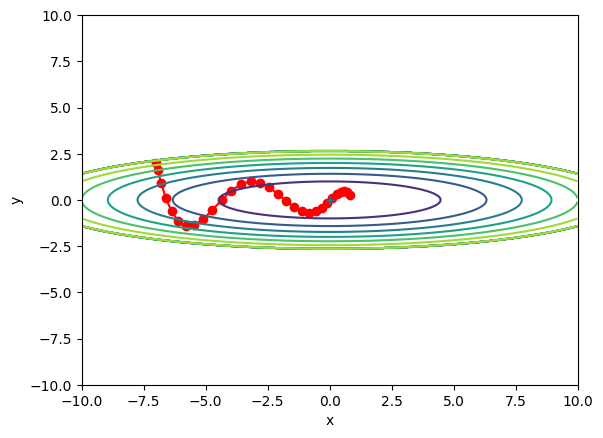

In [8]:
momentum = Momentum(lr=0.1)

draw_optimization(momentum)

更新経路はボールがお椀を転がるような動きをする．SGDと比べると「ジグザグ度合い」が軽減されているのがわかる．これは，x軸方向に受ける力はとても小さいが，常に同じ方向に力を受けるため，同じ方向へ一定して加速することになるからである．逆に，y軸方向には受ける力は大きいが，正と負の方向の力を交互にうけるため，それらが互いに打ち消し合い，y軸方向の速度は安定しない．それによって，SGDのときと比べてx軸方向へ早く近づくことができ，ジグザグの動きを軽減できる．

### AdaGrad
ニューラルネットワークの学習では，学習係数($\eta$)の値が重要になる．学習係数が小さすぎると学習に時間がかかりすぎ，逆に大きすぎると発散して正しい学習が行えない．

この学習係数に関する有効なテクニックとして，**学習係数の減衰** (learning rate decay)という方法がある．これは，学習が進むについれて学習係数を小さくするという方法で，最初は大きく学習し，次第に小さく学習するという手法で，ニューラルネットワークの学習では実際によく使われる．

この考え方を更に発展させ，一つ一つのパラメータに対して，オーダーメイドの学習係数を作るのがAdaGradである．AdaGradはパラメータの要素ごとに適応的に学習係数を調整しながら学習を行う．以下のような式で表すことができる．
$$
\mathbf h \leftarrow \mathbf h + \frac{\partial L}{\partial \mathbf W} \odot \frac{\partial L}{\partial \mathbf W}\\
\mathbf W \leftarrow \mathbf W - \eta\frac{1}{\sqrt{\mathbf h}}\frac{\partial L}{\partial \mathbf W}
$$
$\mathbf W$ は更新する重みパラメータ，$\frac{\partial L}{\partial \mathbf W}$は$\mathbf W$に関する損失関数の勾配，$\eta$ (イータ) は学習係数を表す．ここでは新たに$\mathbf h$が登場する．$\mathbf h$はこれまで経験した勾配の値を2乗和として保持する ($\odot$は行列の要素ごとの掛け算を意味する)．そして，パラメータの更新の際に，$\frac{1}{\sqrt{\mathbf h}}$を乗算することで，学習のスケールを調整する．これは，パラメータの要素の中で大きく更新された要素は学習係数が小さくなるということを意味する．つまり，よく動いたパラメータの学習係数は次第に小さくなるという学習係数の減衰を，パラメータの要素ごとに行うことができる．

AdaGradの実装は下記のようになる．

In [9]:
class AdaGrad:

    """AdaGrad"""

    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

上記のAdaGradを使って最適化をして，その過程を描画する．

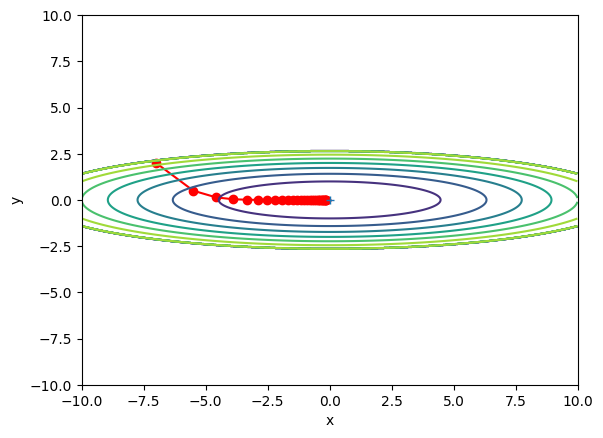

In [10]:
ada_grad = AdaGrad(lr=1.5)

draw_optimization(ada_grad)

結果を見ると，最小値に向かって効率的に動いているのがわかる．y軸方向へは勾配が大きいため，最初は大きく動くが，その大きな動きに比例して，更新のステップが小さくなるように調整が行われる．そのため，y軸方向への更新度合いは弱められていき，ジグザグの動きが軽減される．

### Adam

Momentumはボールがお椀を転がるように物理法則に準じる動きをした．また，AdaGradはパラメータの要素ごとに適応的に更新ステップを調整した．これらを融合することがAdamという手法のベースとなる考え方である．

詳しい説明は省くが下記のように実装できる．

In [11]:
class Adam:

    """Adam (http://arxiv.org/abs/1412.6980v8)"""

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None

    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)

        self.iter += 1
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)

        for key in params.keys():
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])

            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

上記のAdamを使って最適化をして，その過程を描画する．

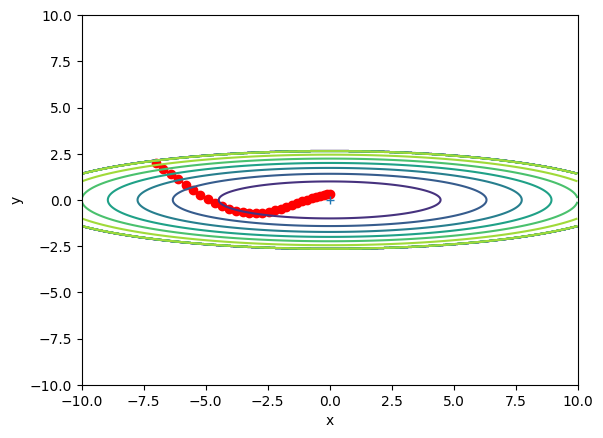

In [12]:
adam = Adam(lr=0.3)

draw_optimization(adam)

結果を見ると，Adamによる更新の過程は，お椀の上をボールが転がるような動きをする．Momentumも同様な動きをしたが，Momentumのときよりもボールの上下の揺れが軽減されている．これは，学習の更新度合いが適応的に調整されることがうまく働いている．

ここまでSGD，Momentum，AdaGrad，Adamを見てきたが，今回の問題に対してはAdaGradが一番良さそうに見える．しかし，これは解くべき問題によってどの手法が良いかは変わってくるので注意が必要である．

## 重みの初期値

ニューラルネットワークの学習で特に重要になってくるのが重みの初期値である．
重みの初期値としてどのような値を設定するかによって，ニューラルネットワークの学習の成否が分かれることがよくある．

一般的に重みを小さく抑えることで過学習を抑え，汎化性能を高めることができるため，重みの初期値もできるだけ小さい値からスタートするのが良さそうである．実際に，これまで重みの初期値は```0.01*np.random.randn(10,100)```のように，ガウス分布から生成される値を0.01倍した小さな値を用いた．重みの値を小さくしたいというのであれば，重みの初期値をすべて0に設定するというのはどうだろうか？これは悪いアイディアである．重みの初期値を0にすると，正しい学習が行えない．

重みの初期値を0にしてはいけないと言うよりは，重みの値を均一な値にしてはいけない．これは誤差逆伝播法では，すべての重みの値が均一に更新されてしまうからである．

たとえば2層のニューラルネットワークにおいて，1層目と2層目の重みが0だと仮定する．そうすると，順伝播時には，入力層の重みが0であるため，2層目のニューロンにはすべて同じ値が伝達される．2層目のニューロンですべて同じ値が入力されるということは，逆伝播のときに2層目の重みはすべて同じように更新されるということになる．そのため，均一の値で更新され，重みは対称的な値(重複した値)を持つことになり，たくさんの重みを保つ意味がなくなってしまう．この，重みが均一になってしまうことを防ぐためにランダムな初期値が必要になる．

以下では，重みの初期値によって隠れ層のアクティベーション (活性化関数の後の出力データ) がどのように変化するか実験を行う．

実験は，5層のニューラルネットワーク(シグモイド関数を活性化関数に使用) に，ランダムに生成した入力データを流し，各層のアクティベーションのデータ分布をヒストグラムで描画する．

まず，下記のように活性化関数を定義する．シグモイド関数以外にも，ReLU，tanh(ハイパボリックタンジェント)も定義しておく．

In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ReLU(x):
    return np.maximum(0, x)


def tanh(x):
    return np.tanh(x)

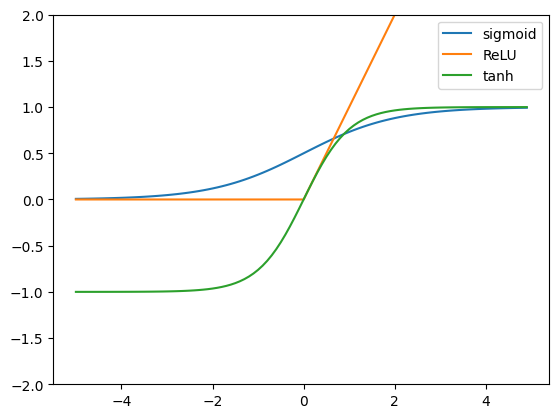

In [14]:
# 各活性化関数の形を確認する
x = np.arange(-5.0, 5.0, 0.1)
y1 = sigmoid(x)
y2 = ReLU(x)
y3 = tanh(x)
plt.plot(x, y1, label='sigmoid')
plt.plot(x, y2, label='ReLU')
plt.plot(x, y3, label='tanh')
plt.ylim(-2.0, 2.0) # y軸の範囲を指定
plt.legend()
plt.show()

以下のようにして5層，各層100個のニューロンを持つニューラルネットワークに対して，1000個のランダム (ガウス分布に従う) なデータを入力する．なお，活性化関数はシグモイド関数を利用し，各層のアクティベーションの結果を ```activations``` という変数に格納する．

まず，標準偏差が1のガウス分布に従うランダムな値を初期値として，アクティベーションの分布がどのように変化するかを観察してみる．

In [15]:
input_data = np.random.randn(1000, 100)  # 1000個のデータ
node_num = 100  # 各隠れ層のノード（ニューロン）の数
hidden_layer_size = 5  # 隠れ層が5層
activations = {}  # ここにアクティベーションの結果を格納する

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = np.random.randn(node_num, node_num) * 1

    a = np.dot(x, w)

    z = sigmoid(a)

    activations[i] = z



アクティベーションの分布をヒストグラムとして可視化する関数を下記のように定義する．

In [16]:
# ヒストグラムを描画
def show_activation_histogram(activations):
  for i, a in activations.items():
      plt.subplot(1, len(activations), i+1)
      plt.title(str(i+1) + "-layer")
      if i != 0: plt.yticks([], [])
      plt.hist(a.flatten(), 30, range=(0,1))
  plt.show()

標準偏差が1のガウス分布に従うランダムな値を初期値とした場合のアクティベーションの分布をヒストグラムとして可視化してみる．

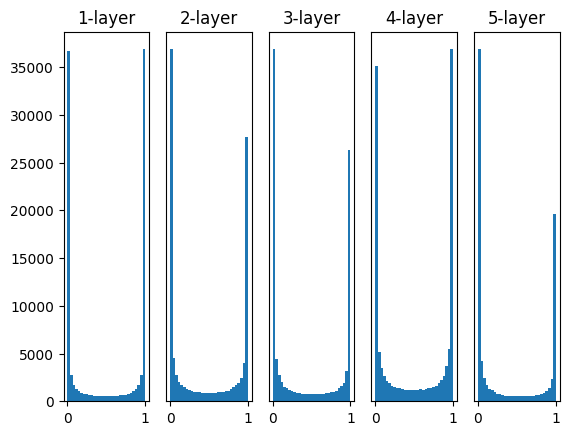

In [17]:
show_activation_histogram(activations)

上記のように，各層のアクティベーションは0と1に偏った分布になっている．ここで使用しているシグモイド関数はS字カーブの関数だが，シグモイド関数の出力が0，または，1に近づくに連れて，その微分の値は0に近づくことになる．このため，0，1に偏ったデータ分布では，逆伝播での勾配の値がどんどん小さくなって消えてしまう．これは**勾配消失**(gradient vanishing) と呼ばれる問題で，層を深くするディープラーニングでは勾配消失は更に深刻な問題になり得る．

では，重みの標準偏差を0.01として同じ実験をするとどうなるか？

In [18]:
activations = {}  # ここにアクティベーションの結果を格納する

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = np.random.randn(node_num, node_num) * 0.01

    a = np.dot(x, w)

    z = sigmoid(a)

    activations[i] = z

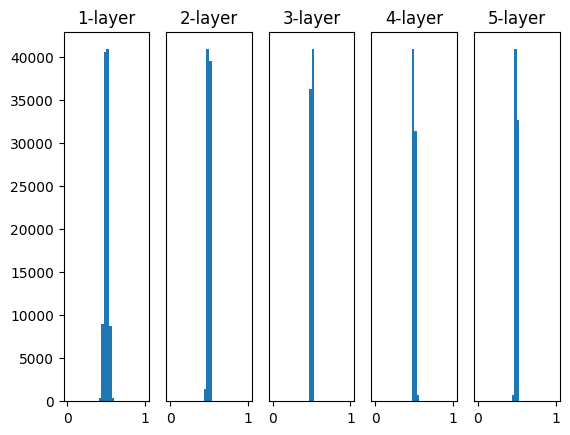

In [19]:
show_activation_histogram(activations)

今度は，0.5付近に集中する分布になった．さっきの例のように0,1への偏りはないので勾配消失の問題は起きない．しかし，アクティベーションに偏りがあるということは，表現力の点で大きな問題がある．なぜなら，複数のニューロンがほとんど同じ値を出力するとすれば，複数のニューロンが存在する意味がなくなってしまうからである (例えば100個のニューロンがほぼ同じ値を出力すれば，それは1つのニューロンでもほぼ同じことを表現することができる)．

なので，勾配消失が起こらないためにも，表現力の制限が起こらないためにも，アクティベーションの分布は適度な広がりを持つことが求められる．

ここで，「Xavierの初期値」を使ってみる (Xavier Glorotらの論文で提案)．Xavierらは各層のアクティベーションを同じ広がりのある分布にするために，適切な重みのスケールを導き出した．これは，前層のノードの個数を$n$とした場合，$\frac{1}{\sqrt{n}}$の標準偏差を持ち分布を使うということである．実際にやってみたい．

In [20]:
activations = {}  # ここにアクティベーションの結果を格納する

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)

    a = np.dot(x, w)

    z = sigmoid(a)

    activations[i] = z

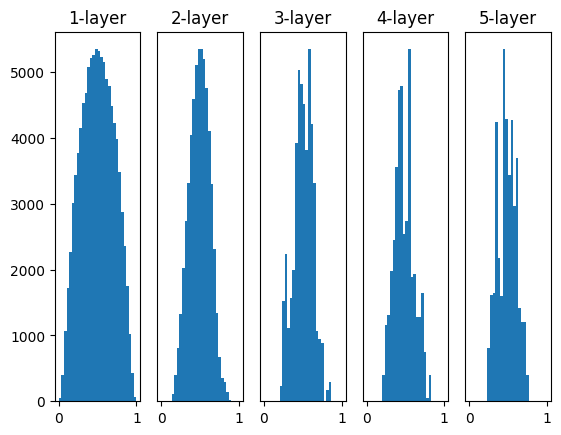

In [21]:
show_activation_histogram(activations)

上記の結果を見ると，上位の層に行くに連れて，ややいびつな形になるが，これまでよりも広がりを持った分布になっていることがわかる．各層に流れるデータには適度な広がりがあるので，シグモイド関数の表現力も制限されることなく，効率的に学習が行えると期待できる．

ここまでは活性化関数にシグモイド関数を使ってきたが，ReLU関数にするとどうなるだろうか？

In [22]:
activations = {}  # ここにアクティベーションの結果を格納する

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = np.random.randn(node_num, node_num) * 0.01

    a = np.dot(x, w)

    z = ReLU(a)

    activations[i] = z

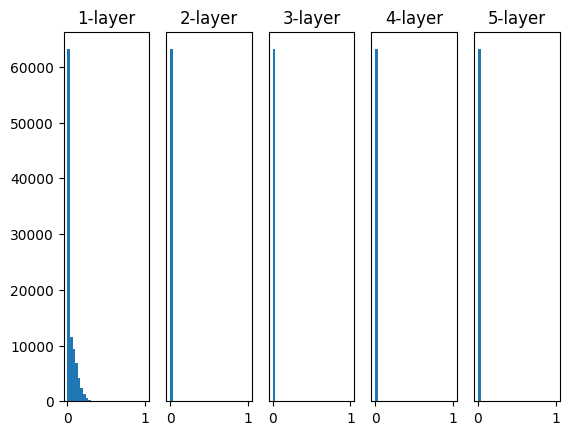

In [23]:
show_activation_histogram(activations)

標準偏差が0.01のガウス分布を重みの初期値とした場合は上記のようにアクティベーションはとても小さな値になる．ニューラルネットワーク上をとても小さなデータが流れるということは，逆伝播の際の重みの勾配も同様に小さくなる．このため，実際には学習がほとんど進まないと考えられる．

In [24]:
activations = {}  # ここにアクティベーションの結果を格納する

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)

    a = np.dot(x, w)

    z = ReLU(a)

    activations[i] = z

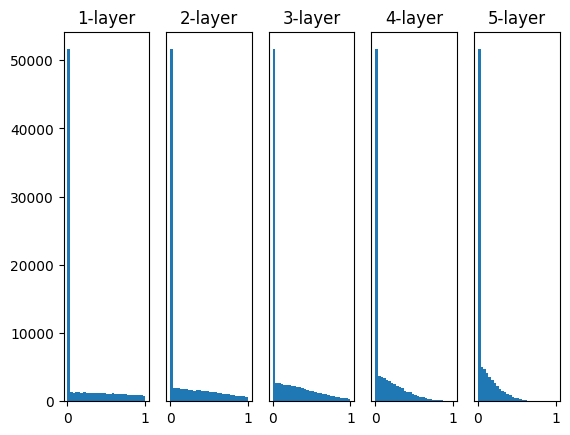

In [25]:
show_activation_histogram(activations)

Xavierの初期値を使った場合，層が深くなるにつれて偏りが少しずつ大きくなる．実際，層をディープにしていくと，アクティベーションの偏りも大きくなり，学習の際の勾配消失が問題となる．

そこで，Kaiming Heらが推奨する初期値である「Heの初期値」を導入する．これは$\sqrt{\frac{2}{n}}$を標準偏差とするガウス分布を用いる．Xavierの初期値が$\sqrt{\frac{1}{n}}$であったことを考えると，ReLUの場合は負の領域が0になるため，より広がりを持たせるために倍の係数が必要になると直感的には解釈できる．

では，Heの初期値の場合を確認する．

In [26]:
activations = {}  # ここにアクティベーションの結果を格納する

x = input_data

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)


    a = np.dot(x, w)

    z = ReLU(a)

    activations[i] = z

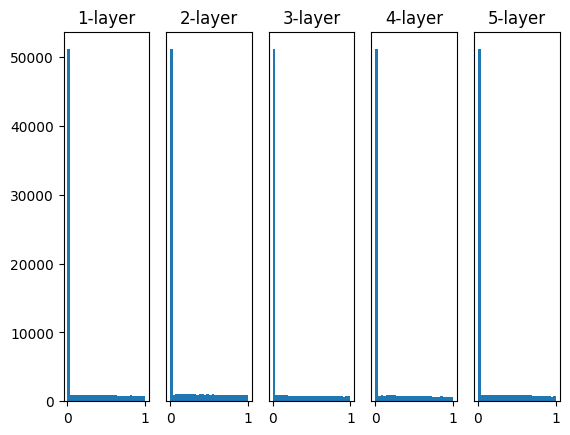

In [27]:
show_activation_histogram(activations)

上記のようにHeの初期値を使うと各層で分布の広がりが均一になっている．データの広がりが層を深くしても均一に保たれるので，逆伝播の際も適切な値が流れると期待できる．

## Batch Normalization
重みの初期値を適切に設定することで各層のアクティベーションの分布は適度な広がりを持ち，学習がスムーズに行えることがわかった．Batch Normalizationは各層で適度な広がりをもつように"強制的に"アクティベーションの分布を調整する．

Batch Normalization (Batch Norm) の特徴：
- 学習を速く進行させることができる (学習係数を大きくすることができる)
- 初期値にそれほど依存しない (初期値に対してそこまで神経質にならなくて良い)
- 過学習を抑制する

Batch Normは各層でのアクティベーションの分布を適度な広がりを持つように調整することである．そのため，下図のようにBatch Norm レイヤとして，データの分布の正規化を行うレイヤをニューラルネットワークに挿入する．

<img alt="batchnorm.png" width="800" src="http://drive.google.com/uc?export=view&id=1hBv1G2W01VHwq_37FbvVKbJBWziM9Hce">

Batch Norm は学習を行う際のミニバッチを単位として，ミニバッチごとに正規化を行う．具体的にはデータの分布が平均0，分散1になりように正規化する．数式で表すと下記のようになる．

$$
\mu_B \leftarrow \frac{1}{m}\sum^m_{i=1}x_i \\
\sigma^2_B \leftarrow \frac{1}{m} \sum^m_{i=1}(x_i-\mu_B)^2\\
\hat{x_i} \leftarrow \frac{x_i - \mu_B}{\sqrt{\sigma^2_B+\varepsilon}}
$$

ここで，ミニバッチとして $B=\{x_1,x_2,\cdots,x_m\}$という$m$個の入力データの集合に対して，平均$\mu_B$，分散$\sigma^2_B$を求める．そして，入力データを平均0，分散1になるように正規化する．なお，上記の式の$\varepsilon$は小さな値で，これは0で除算されることを防止するためのものである．

上記の式のような処理を活性化関数の前，もしくは後に挿入することで，データの分布の偏りを減らせる．

さらに，Batch Norm レイヤはこの正規化されたデータに対して，固有のスケールとシフトで変換を行う．これは下記の式で表される．

$$
y_i \leftarrow \gamma \hat{x_i} + \beta
$$

ここで，$\gamma$と$\beta$は学習によって調整されるパラメータであり，最初は$\gamma = 1, \beta = 0$からスタートする．

上記は順伝播の処理であるが，逆伝播についてはここでは説明を省略する．

下記のようにBatch Norm レイヤを実装する (ここはコピペ頂いて問題ありません)．

In [28]:
class BatchNormalization:
    """
    http://arxiv.org/abs/1502.03167
    """
    def __init__(self, gamma, beta, momentum=0.9, running_mean=None, running_var=None):
        self.gamma = gamma
        self.beta = beta
        self.momentum = momentum
        self.input_shape = None # Conv層の場合は4次元、全結合層の場合は2次元

        # テスト時に使用する平均と分散
        self.running_mean = running_mean
        self.running_var = running_var

        # backward時に使用する中間データ
        self.batch_size = None
        self.xc = None
        self.std = None
        self.dgamma = None
        self.dbeta = None

    def forward(self, x, train_flg=True):
        self.input_shape = x.shape
        if x.ndim != 2:
            N, C, H, W = x.shape
            x = x.reshape(N, -1)

        out = self.__forward(x, train_flg)

        return out.reshape(*self.input_shape)

    def __forward(self, x, train_flg):
        if self.running_mean is None:
            N, D = x.shape
            self.running_mean = np.zeros(D)
            self.running_var = np.zeros(D)

        if train_flg:
            mu = x.mean(axis=0)
            xc = x - mu
            var = np.mean(xc**2, axis=0)
            std = np.sqrt(var + 10e-7)
            xn = xc / std

            self.batch_size = x.shape[0]
            self.xc = xc
            self.xn = xn
            self.std = std
            self.running_mean = self.momentum * self.running_mean + (1-self.momentum) * mu
            self.running_var = self.momentum * self.running_var + (1-self.momentum) * var
        else:
            xc = x - self.running_mean
            xn = xc / ((np.sqrt(self.running_var + 10e-7)))

        out = self.gamma * xn + self.beta
        return out

    def backward(self, dout):
        if dout.ndim != 2:
            N, C, H, W = dout.shape
            dout = dout.reshape(N, -1)

        dx = self.__backward(dout)

        dx = dx.reshape(*self.input_shape)
        return dx

    def __backward(self, dout):
        dbeta = dout.sum(axis=0)
        dgamma = np.sum(self.xn * dout, axis=0)
        dxn = self.gamma * dout
        dxc = dxn / self.std
        dstd = -np.sum((dxn * self.xc) / (self.std * self.std), axis=0)
        dvar = 0.5 * dstd / self.std
        dxc += (2.0 / self.batch_size) * self.xc * dvar
        dmu = np.sum(dxc, axis=0)
        dx = dxc - dmu / self.batch_size

        self.dgamma = dgamma
        self.dbeta = dbeta

        return dx

実際にBatch Norm レイヤを使って実験する．まず，これまで作ったニューラルネットワークを再度定義する．

In [29]:
class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = sigmoid(x)
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx

class Affine:
    def __init__(self, W, b):
        self.W =W
        self.b = b
        self.x = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        return dx

def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T

    x = x - np.max(x) # オーバーフロー対策
    return np.exp(x) / np.sum(np.exp(x))

def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch_size

class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None # softmaxの出力
        self.t = None # 教師データ

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        dx = (self.y - self.t) / batch_size #データ1個あたりの誤差にする

        return dx



In [30]:
from collections import OrderedDict

class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std = 0.01):
        # 重みの初期化
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

        # レイヤの生成
        self.layers = OrderedDict()
        self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
        self.layers['Relu1'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])

        self.lastLayer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    # x:入力データ, t:教師データ
    def loss(self, x, t):
        y = self.predict(x)
        return self.lastLayer.forward(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def gradient(self, x, t):
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.lastLayer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 設定
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W2'], grads['b2'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads

次にBatch Norm レイヤを含むニューラルネットワークを定義する．

In [31]:
class TwoLayerNet_BatchNorm:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std = 0.01):
        # 重みの初期化
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

        # レイヤの生成
        self.layers = OrderedDict()
        self.layers['Affine1'] = Affine(self.params['W1'], self.params['b1'])
        self.layers['Batch_Norm1'] = BatchNormalization(1.0, 0.0)
        self.layers['Relu1'] = Relu()
        self.layers['Batch_Norm2'] = BatchNormalization(1.0, 0.0)
        self.layers['Affine2'] = Affine(self.params['W2'], self.params['b2'])

        self.lastLayer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    # x:入力データ, t:教師データ
    def loss(self, x, t):
        y = self.predict(x)
        return self.lastLayer.forward(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def gradient(self, x, t):
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.lastLayer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 設定
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W2'], grads['b2'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads

2つのニューラルネットワークの重みの初期値の標準偏差を様々に変化させ，MNISTで学習したときのエポックごとの精度を比較する．

In [32]:
from google.colab import drive
import sys

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/data'

Mounted at /content/drive


In [33]:
def load_mnist(save_dir, one_hot_label=True):
  import numpy as np
  from sklearn.model_selection import train_test_split
  import pickle
  import os

  with open(os.path.join(save_dir, 'mnist_X.pkl'), 'rb') as f:
    X = pickle.load(f)
  with open(os.path.join(save_dir, 'mnist_y.pkl'), 'rb') as f:
    y = pickle.load(f)

  x_train, x_test, t_train, t_test = train_test_split(X, y, test_size=10000, random_state=42)

  if one_hot_label:
    t_train = np.eye(10)[t_train]
    t_test = np.eye(10)[t_test]

  return (x_train, t_train), (x_test, t_test)

============== 1/16 ==============
epoch:0 | 0.071 - 0.122
epoch:1 | 0.128 - 0.132
epoch:2 | 0.164 - 0.144
epoch:3 | 0.213 - 0.157
epoch:4 | 0.265 - 0.174
epoch:5 | 0.322 - 0.181
epoch:6 | 0.368 - 0.191
epoch:7 | 0.397 - 0.198
epoch:8 | 0.446 - 0.212
epoch:9 | 0.477 - 0.22
epoch:10 | 0.504 - 0.226
epoch:11 | 0.535 - 0.241
epoch:12 | 0.555 - 0.261
epoch:13 | 0.583 - 0.272
epoch:14 | 0.586 - 0.283
epoch:15 | 0.611 - 0.292
epoch:16 | 0.63 - 0.298
epoch:17 | 0.642 - 0.304
epoch:18 | 0.659 - 0.314
epoch:19 | 0.658 - 0.318
============== 2/16 ==============
epoch:0 | 0.128 - 0.092
epoch:1 | 0.206 - 0.108


/tmp/ipykernel_1394/900833162.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


epoch:2 | 0.273 - 0.127
epoch:3 | 0.31 - 0.149
epoch:4 | 0.356 - 0.172
epoch:5 | 0.386 - 0.188
epoch:6 | 0.429 - 0.201
epoch:7 | 0.464 - 0.22
epoch:8 | 0.505 - 0.237
epoch:9 | 0.529 - 0.26
epoch:10 | 0.548 - 0.281
epoch:11 | 0.566 - 0.299
epoch:12 | 0.586 - 0.32
epoch:13 | 0.6 - 0.333
epoch:14 | 0.62 - 0.345
epoch:15 | 0.641 - 0.364
epoch:16 | 0.657 - 0.382
epoch:17 | 0.663 - 0.394
epoch:18 | 0.675 - 0.406
epoch:19 | 0.684 - 0.42
============== 3/16 ==============
epoch:0 | 0.117 - 0.07
epoch:1 | 0.151 - 0.091
epoch:2 | 0.19 - 0.123
epoch:3 | 0.231 - 0.153
epoch:4 | 0.295 - 0.184
epoch:5 | 0.351 - 0.202
epoch:6 | 0.398 - 0.233
epoch:7 | 0.436 - 0.267
epoch:8 | 0.474 - 0.299
epoch:9 | 0.506 - 0.332
epoch:10 | 0.526 - 0.351
epoch:11 | 0.544 - 0.38
epoch:12 | 0.554 - 0.41
epoch:13 | 0.578 - 0.434
epoch:14 | 0.589 - 0.452
epoch:15 | 0.599 - 0.481
epoch:16 | 0.617 - 0.501
epoch:17 | 0.635 - 0.512
epoch:18 | 0.644 - 0.531
epoch:19 | 0.658 - 0.553
============== 4/16 ==============
epoch:0 | 

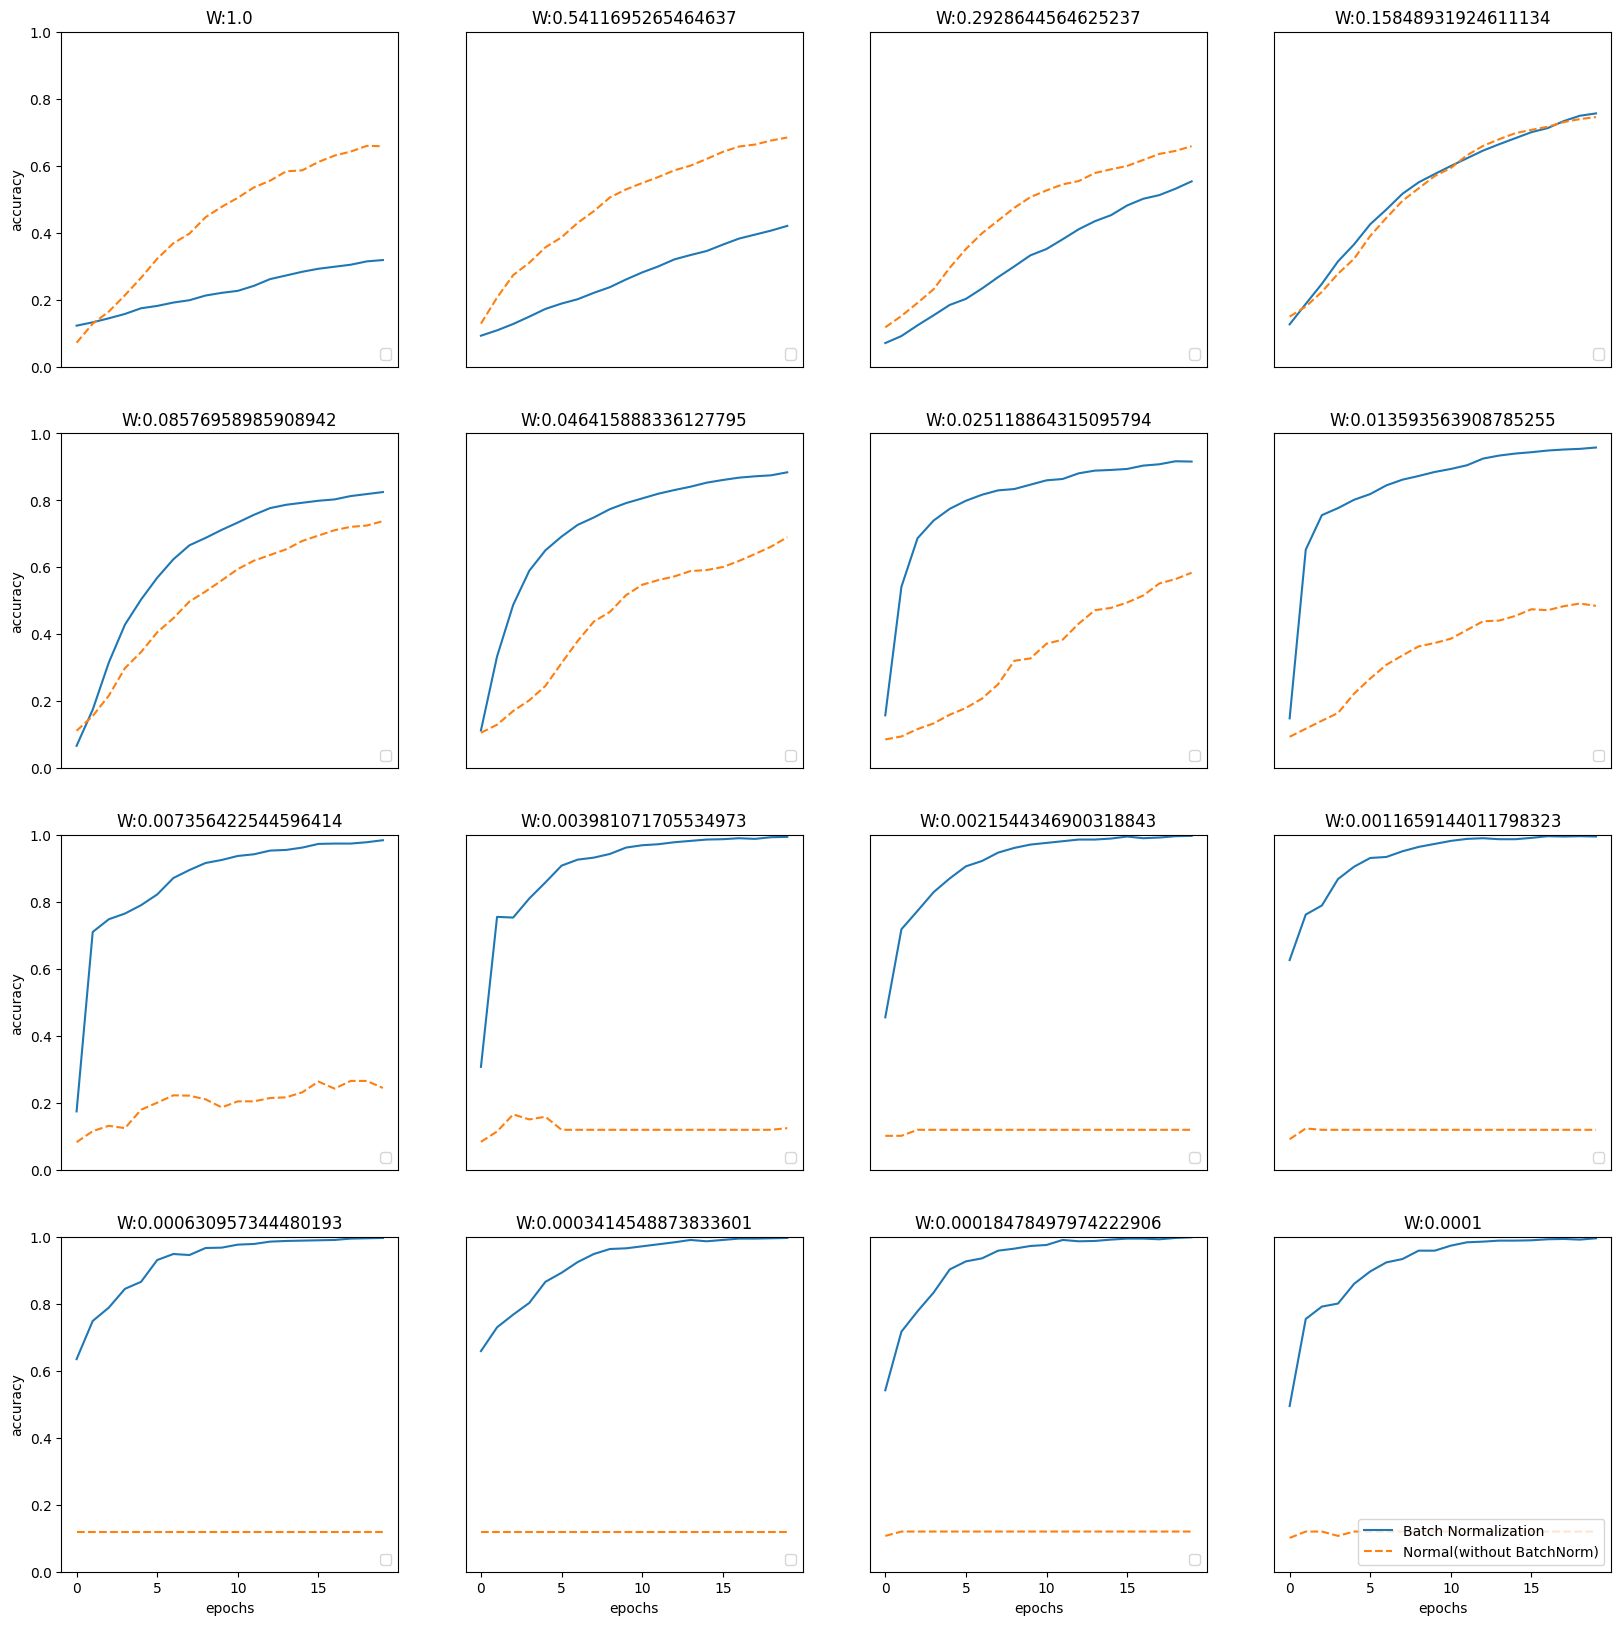

In [34]:
(x_train, t_train), (x_test, t_test) = load_mnist(save_dir, one_hot_label=True)

# 学習データを削減
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = TwoLayerNet_BatchNorm(input_size=784, hidden_size=100, output_size=10,
                                    weight_init_std=weight_init_std)
    network = TwoLayerNet(input_size=784, hidden_size=100, output_size=10,
                                    weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)

    train_acc_list = []
    bn_train_acc_list = []

    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0

    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)

            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, bn_train_acc_list


# 3.グラフの描画==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

fig = plt.figure()

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')

fig.set_size_inches(20, 20)

plt.show()

この結果，ほとんどすべてのケースでBatch Norm を使用することで，学習の進行を促進させることができ，重みの初期値にロバストになる．

## 正則化
機械学習では**過学習**が問題になることがある．過学習とは，訓練データだけに適応しすぎてしまい，訓練データに含まれない他のデータにはうまく対応できない状態のことである．機械学習は汎化性能が必要であり，訓練データに含まれないまだ見ぬデータであっても，正しく識別できるモデルが望まれる．

過学習が起きる原因として主に下記の2つがある．
- パラメータを大量に持ち，表現力の高いモデルであること
- 訓練データが少ないこと

ここでは，この2つの要件をわざと満たして，過学習を発生させる．そのため，MNISTデータセットの訓練データを本来の60000個から300個だけに限定する．また，ネットワークの複雑性を高めるために7層のネットワークで，各層のニューロンの下図は100個，活性化関数はReLUとする．

In [35]:
class MultiLayerNet:
    """全結合による多層ニューラルネットワーク
    Parameters
    ----------
    input_size : 入力サイズ（MNISTの場合は784）
    hidden_size_list : 隠れ層のニューロンの数のリスト（e.g. [100, 100, 100]）
    output_size : 出力サイズ（MNISTの場合は10）
    activation : 'relu' or 'sigmoid'
    weight_init_std : 重みの標準偏差を指定（e.g. 0.01）
        'relu'または'he'を指定した場合は「Heの初期値」を設定
        'sigmoid'または'xavier'を指定した場合は「Xavierの初期値」を設定
    """
    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu'):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.params = {}

        # 重みの初期化
        self.__init_weight(weight_init_std)

        # レイヤの生成
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
            self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()

    def __init_weight(self, weight_init_std):
        """重みの初期値設定
        Parameters
        ----------
        weight_init_std : 重みの標準偏差を指定（e.g. 0.01）
            'relu'または'he'を指定した場合は「Heの初期値」を設定
            'sigmoid'または'xavier'を指定した場合は「Xavierの初期値」を設定
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2.0 / all_size_list[idx - 1])  # ReLUを使う場合に推奨される初期値
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(1.0 / all_size_list[idx - 1])  # sigmoidを使う場合に推奨される初期値

            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """損失関数を求める
        Parameters
        ----------
        x : 入力データ
        t : 教師ラベル
        Returns
        -------
        損失関数の値
        """
        y = self.predict(x)

        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]

        return self.last_layer.forward(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def gradient(self, x, t):
        """勾配を求める（誤差逆伝搬法）
        Parameters
        ----------
        x : 入力データ
        t : 教師ラベル
        Returns
        -------
        各層の勾配を持ったディクショナリ変数
            grads['W1']、grads['W2']、...は各層の重み
            grads['b1']、grads['b2']、...は各層のバイアス
        """
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 設定
        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

        return grads

epoch:0, train acc:0.08333333333333333, test acc:0.0902
epoch:1, train acc:0.09666666666666666, test acc:0.0945
epoch:2, train acc:0.11333333333333333, test acc:0.1044
epoch:3, train acc:0.13666666666666666, test acc:0.1164
epoch:4, train acc:0.14666666666666667, test acc:0.1221
epoch:5, train acc:0.16333333333333333, test acc:0.1353
epoch:6, train acc:0.17, test acc:0.1441
epoch:7, train acc:0.17666666666666667, test acc:0.1501
epoch:8, train acc:0.18333333333333332, test acc:0.1619
epoch:9, train acc:0.19666666666666666, test acc:0.1707
epoch:10, train acc:0.21333333333333335, test acc:0.1811
epoch:11, train acc:0.25333333333333335, test acc:0.1944
epoch:12, train acc:0.26, test acc:0.1974
epoch:13, train acc:0.26, test acc:0.1969
epoch:14, train acc:0.29, test acc:0.2207
epoch:15, train acc:0.2966666666666667, test acc:0.2217
epoch:16, train acc:0.33, test acc:0.2426
epoch:17, train acc:0.34, test acc:0.241
epoch:18, train acc:0.39666666666666667, test acc:0.2736
epoch:19, train acc

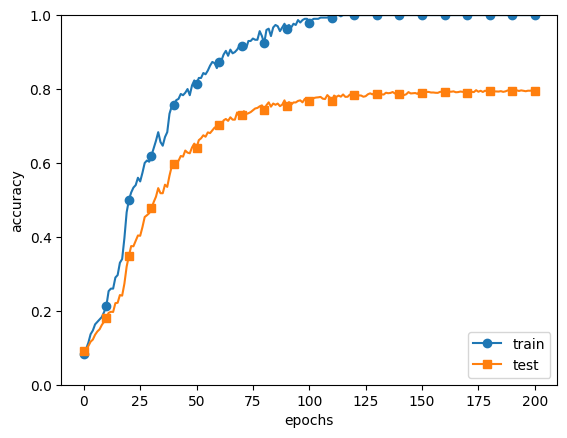

In [36]:
(x_train, t_train), (x_test, t_test) = load_mnist(save_dir, one_hot_label=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 3.グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

上記の結果から，訓練データを用いた場合の認識精度は100エポックを過ぎたあたりからほとんど100%であるが，テストデータを用いた場合は100%の認識精度から大きく下回る．このような認識精度の大きな違いは，訓練データだけに適応しすぎてしまった結果である．

## Weight decay

過学習制御のためによく用いられる手法に**Weight decay** (荷重減衰) という方法がある．これは学習の過程において，大きな重みを持つことに対してペナルティを課すことで，過学習を制御するものである．そもそも，過学習は重みパラメータが大きな値を取ることによって発生することが多くあるため，このような制御を行う．

復習となるが，ニューラルネットワークの学習は，損失関数の値を小さくすることを目的として行われる．このとき，例えば重みの2乗ノルム (L2ノルム) を損失関数に加算する．そうすると，重みが大きくなることを抑えることができる．記号で表すと，重み $\mathbf W$とすれば，L2ノルムのWeight decayは $\frac{1}{2}\lambda \mathbf \|W\|_2^2$になり，この $\frac{1}{2}\lambda \mathbf \|W\|_2^2$ を損失関数に加算する．ここで， $\lambda$は正則化の強さをコントロールするハイパーパラメータであり， $\lambda$ を大きく設定すればするほど大きな重みを取ることに対して強いペナルティを課すことになる．また， $\frac{1}{2}\lambda \mathbf \|W\|_2^2$ の先頭の $\frac{1}{2}$ は， $\frac{1}{2}\lambda \mathbf \|W\|_2^2$の微分の結果を $\lambda \mathbf W$にするための調整用の定数である．

Weight decayは，すべての重みに対して，損失関数に$\frac{1}{2}\lambda \mathbf \|W\|_2^2$を加算する．そのため，重みの勾配を求める計算では，これまでの誤差逆伝播法による結果に，正則化項の微分である $\lambda \mathbf W$ を加算する．

In [37]:
class MultiLayerNetWD:
    """全結合による多層ニューラルネットワーク
    Parameters
    ----------
    input_size : 入力サイズ（MNISTの場合は784）
    hidden_size_list : 隠れ層のニューロンの数のリスト（e.g. [100, 100, 100]）
    output_size : 出力サイズ（MNISTの場合は10）
    activation : 'relu' or 'sigmoid'
    weight_init_std : 重みの標準偏差を指定（e.g. 0.01）
        'relu'または'he'を指定した場合は「Heの初期値」を設定
        'sigmoid'または'xavier'を指定した場合は「Xavierの初期値」を設定
    weight_decay_lambda : Weight Decay（L2ノルム）の強さ
    """
    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.weight_decay_lambda = weight_decay_lambda
        self.params = {}

        # 重みの初期化
        self.__init_weight(weight_init_std)

        # レイヤの生成
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
            self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()

    def __init_weight(self, weight_init_std):
        """重みの初期値設定
        Parameters
        ----------
        weight_init_std : 重みの標準偏差を指定（e.g. 0.01）
            'relu'または'he'を指定した場合は「Heの初期値」を設定
            'sigmoid'または'xavier'を指定した場合は「Xavierの初期値」を設定
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2.0 / all_size_list[idx - 1])  # ReLUを使う場合に推奨される初期値
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(1.0 / all_size_list[idx - 1])  # sigmoidを使う場合に推奨される初期値

            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """損失関数を求める
        Parameters
        ----------
        x : 入力データ
        t : 教師ラベル
        Returns
        -------
        損失関数の値
        """
        y = self.predict(x)

        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W ** 2)

        return self.last_layer.forward(y, t) + weight_decay

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def gradient(self, x, t):
        """勾配を求める（誤差逆伝搬法）
        Parameters
        ----------
        x : 入力データ
        t : 教師ラベル
        Returns
        -------
        各層の勾配を持ったディクショナリ変数
            grads['W1']、grads['W2']、...は各層の重み
            grads['b1']、grads['b2']、...は各層のバイアス
        """
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 設定
        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.layers['Affine' + str(idx)].W
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

        return grads

epoch:0, train acc:0.07333333333333333, test acc:0.0833
epoch:1, train acc:0.08666666666666667, test acc:0.0896
epoch:2, train acc:0.11, test acc:0.1009
epoch:3, train acc:0.14, test acc:0.1121
epoch:4, train acc:0.17333333333333334, test acc:0.1254
epoch:5, train acc:0.21, test acc:0.1377
epoch:6, train acc:0.25, test acc:0.15
epoch:7, train acc:0.27666666666666667, test acc:0.1618
epoch:8, train acc:0.27666666666666667, test acc:0.1652
epoch:9, train acc:0.2866666666666667, test acc:0.1746
epoch:10, train acc:0.29333333333333333, test acc:0.1854
epoch:11, train acc:0.31, test acc:0.1992
epoch:12, train acc:0.31666666666666665, test acc:0.2036
epoch:13, train acc:0.3333333333333333, test acc:0.2128
epoch:14, train acc:0.34, test acc:0.2083
epoch:15, train acc:0.3433333333333333, test acc:0.2173
epoch:16, train acc:0.35, test acc:0.2152
epoch:17, train acc:0.3566666666666667, test acc:0.225
epoch:18, train acc:0.37666666666666665, test acc:0.2416
epoch:19, train acc:0.38, test acc:0.25

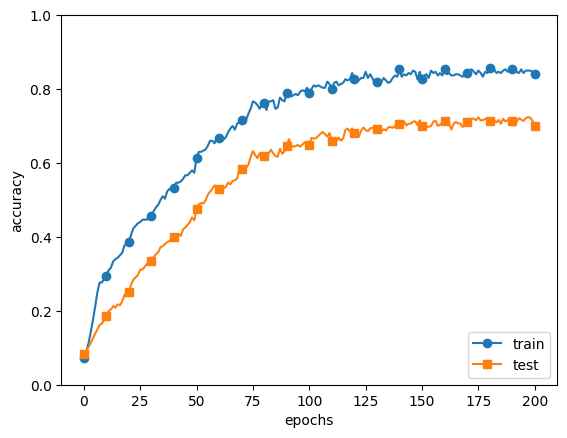

In [38]:
network = MultiLayerNetWD(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10, weight_decay_lambda=0.1)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 3.グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

上記の結果から，訓練データの認識精度とテストデータの認識精度には隔たりがあるが，Weight decayを用いなかったときの結果と比較すると，その隔たりは小さいくなっている．これは，過学習が抑制されたと言える．

## Dropout

Weight decayは簡単に実装できるが，ニューラルネットワークのモデルが複雑になってくると，Weight decayだけでは対応が難しくなる．そこで，Dropoutという手法がよく用いられる．

Dropoutはニューロンをランダムに消去しながら学習する手法である．訓練時に隠れ層のニューロンをランダムに選び出し，その選びだしたニューロンを消去する．消去されたニューロンは信号の伝達が行われなくなる．なお，訓練時にはデータが流れるたびに消去するニューロンをランダムに選択する．そして，テスト時にはすべてのニューロンの信号を伝達するが，ニューロンの出力に対して，訓練時に消去した割合を乗算して出力する．

<img alt="dropout.png" width="800" src="http://drive.google.com/uc?export=view&id=16EGmpKDkYLQA8yipSZ3Flrt3yxpCJ2K1">

Dropoutレイヤを下記のように実装する．

In [39]:
class Dropout:
    """
    http://arxiv.org/abs/1207.0580
    """
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio)

    def backward(self, dout):
        return dout * self.mask


また，Dropoutの他にもBatch Norm ，Weight decayを設定できるMultiLayerExtendsを下記のように実装する (これはコピペで問題ないと思います)．

In [40]:
class MultiLayerNetExtend:
    """拡張版の全結合による多層ニューラルネットワーク

    Weiht Decay、Dropout、Batch Normalizationの機能を持つ
    Parameters
    ----------
    input_size : 入力サイズ（MNISTの場合は784）
    hidden_size_list : 隠れ層のニューロンの数のリスト（e.g. [100, 100, 100]）
    output_size : 出力サイズ（MNISTの場合は10）
    activation : 'relu' or 'sigmoid'
    weight_init_std : 重みの標準偏差を指定（e.g. 0.01）
        'relu'または'he'を指定した場合は「Heの初期値」を設定
        'sigmoid'または'xavier'を指定した場合は「Xavierの初期値」を設定
    weight_decay_lambda : Weight Decay（L2ノルム）の強さ
    use_dropout: Dropoutを使用するかどうか
    dropout_ratio : Dropoutの割合
    use_batchNorm: Batch Normalizationを使用するかどうか
    """
    def __init__(self, input_size, hidden_size_list, output_size,
                 activation='relu', weight_init_std='relu', weight_decay_lambda=0,
                 use_dropout = False, dropout_ratio = 0.5, use_batchnorm=False):
        self.input_size = input_size
        self.output_size = output_size
        self.hidden_size_list = hidden_size_list
        self.hidden_layer_num = len(hidden_size_list)
        self.use_dropout = use_dropout
        self.weight_decay_lambda = weight_decay_lambda
        self.use_batchnorm = use_batchnorm
        self.params = {}

        # 重みの初期化
        self.__init_weight(weight_init_std)

        # レイヤの生成
        activation_layer = {'sigmoid': Sigmoid, 'relu': Relu}
        self.layers = OrderedDict()
        for idx in range(1, self.hidden_layer_num+1):
            self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)],
                                                      self.params['b' + str(idx)])
            if self.use_batchnorm:
                self.params['gamma' + str(idx)] = np.ones(hidden_size_list[idx-1])
                self.params['beta' + str(idx)] = np.zeros(hidden_size_list[idx-1])
                self.layers['BatchNorm' + str(idx)] = BatchNormalization(self.params['gamma' + str(idx)], self.params['beta' + str(idx)])

            self.layers['Activation_function' + str(idx)] = activation_layer[activation]()

            if self.use_dropout:
                self.layers['Dropout' + str(idx)] = Dropout(dropout_ratio)

        idx = self.hidden_layer_num + 1
        self.layers['Affine' + str(idx)] = Affine(self.params['W' + str(idx)], self.params['b' + str(idx)])

        self.last_layer = SoftmaxWithLoss()

    def __init_weight(self, weight_init_std):
        """重みの初期値設定
        Parameters
        ----------
        weight_init_std : 重みの標準偏差を指定（e.g. 0.01）
            'relu'または'he'を指定した場合は「Heの初期値」を設定
            'sigmoid'または'xavier'を指定した場合は「Xavierの初期値」を設定
        """
        all_size_list = [self.input_size] + self.hidden_size_list + [self.output_size]
        for idx in range(1, len(all_size_list)):
            scale = weight_init_std
            if str(weight_init_std).lower() in ('relu', 'he'):
                scale = np.sqrt(2.0 / all_size_list[idx - 1])  # ReLUを使う場合に推奨される初期値
            elif str(weight_init_std).lower() in ('sigmoid', 'xavier'):
                scale = np.sqrt(1.0 / all_size_list[idx - 1])  # sigmoidを使う場合に推奨される初期値
            self.params['W' + str(idx)] = scale * np.random.randn(all_size_list[idx-1], all_size_list[idx])
            self.params['b' + str(idx)] = np.zeros(all_size_list[idx])

    def predict(self, x, train_flg=False):
        for key, layer in self.layers.items():
            if "Dropout" in key or "BatchNorm" in key:
                x = layer.forward(x, train_flg)
            else:
                x = layer.forward(x)

        return x

    def loss(self, x, t, train_flg=False):
        """損失関数を求める
        引数のxは入力データ、tは教師ラベル
        """
        y = self.predict(x, train_flg)

        weight_decay = 0
        for idx in range(1, self.hidden_layer_num + 2):
            W = self.params['W' + str(idx)]
            weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)

        return self.last_layer.forward(y, t) + weight_decay

    def accuracy(self, x, t):
        y = self.predict(x, train_flg=False)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

    def gradient(self, x, t):
        # forward
        self.loss(x, t, train_flg=True)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 設定
        grads = {}
        for idx in range(1, self.hidden_layer_num+2):
            grads['W' + str(idx)] = self.layers['Affine' + str(idx)].dW + self.weight_decay_lambda * self.params['W' + str(idx)]
            grads['b' + str(idx)] = self.layers['Affine' + str(idx)].db

            if self.use_batchnorm and idx != self.hidden_layer_num+1:
                grads['gamma' + str(idx)] = self.layers['BatchNorm' + str(idx)].dgamma
                grads['beta' + str(idx)] = self.layers['BatchNorm' + str(idx)].dbeta

        return grads

さらに，これまで毎回プログラミングしていたニューラルネットワークの訓練を行う処理を行う，Trainerクラスを実装する．これによって，毎回同じ訓練のためのプログラムをしなくてもよくなる (これもコピペで良いと思います)．

In [41]:
class Trainer:
    """ニューラルネットの訓練を行うクラス
    """
    def __init__(self, network, x_train, t_train, x_test, t_test,
                 epochs=20, mini_batch_size=100,
                 optimizer='SGD', optimizer_param={'lr':0.01},
                 evaluate_sample_num_per_epoch=None, verbose=True):
        self.network = network
        self.verbose = verbose
        self.x_train = x_train
        self.t_train = t_train
        self.x_test = x_test
        self.t_test = t_test
        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.evaluate_sample_num_per_epoch = evaluate_sample_num_per_epoch

        # optimizer
        optimizer_class_dict = {'sgd':SGD, 'momentum':Momentum,
                                'adagrad':AdaGrad, 'adam':Adam}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)

        self.train_size = x_train.shape[0]
        self.iter_per_epoch = max(self.train_size / mini_batch_size, 1)
        self.max_iter = int(epochs * self.iter_per_epoch)
        self.current_iter = 0
        self.current_epoch = 0

        self.train_loss_list = []
        self.train_acc_list = []
        self.test_acc_list = []

    def train_step(self):
        batch_mask = np.random.choice(self.train_size, self.batch_size)
        x_batch = self.x_train[batch_mask]
        t_batch = self.t_train[batch_mask]

        grads = self.network.gradient(x_batch, t_batch)
        self.optimizer.update(self.network.params, grads)

        loss = self.network.loss(x_batch, t_batch)
        self.train_loss_list.append(loss)
        if self.verbose: print("train loss:" + str(loss))

        if self.current_iter % self.iter_per_epoch == 0:
            self.current_epoch += 1

            x_train_sample, t_train_sample = self.x_train, self.t_train
            x_test_sample, t_test_sample = self.x_test, self.t_test
            if not self.evaluate_sample_num_per_epoch is None:
                t = self.evaluate_sample_num_per_epoch
                x_train_sample, t_train_sample = self.x_train[:t], self.t_train[:t]
                x_test_sample, t_test_sample = self.x_test[:t], self.t_test[:t]

            train_acc = self.network.accuracy(x_train_sample, t_train_sample)
            test_acc = self.network.accuracy(x_test_sample, t_test_sample)
            self.train_acc_list.append(train_acc)
            self.test_acc_list.append(test_acc)

            if self.verbose: print("=== epoch:" + str(self.current_epoch) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc) + " ===")
        self.current_iter += 1

    def train(self):
        for i in range(self.max_iter):
            self.train_step()

        test_acc = self.network.accuracy(self.x_test, self.t_test)

        if self.verbose:
            print("=============== Final Test Accuracy ===============")
            print("test acc:" + str(test_acc))

train loss:2.2755025292057796
=== epoch:1, train acc:0.09333333333333334, test acc:0.0996 ===
train loss:2.296799957375344
train loss:2.2973840215844286
train loss:2.3180665839506527
=== epoch:2, train acc:0.09333333333333334, test acc:0.1025 ===
train loss:2.2908467731626896
train loss:2.3078430153637854
train loss:2.2938212618818232
=== epoch:3, train acc:0.11333333333333333, test acc:0.1049 ===
train loss:2.3130333849350624
train loss:2.3106708744913043
train loss:2.2985473004403256
=== epoch:4, train acc:0.11666666666666667, test acc:0.1062 ===
train loss:2.309251046935923
train loss:2.269305716512723
train loss:2.2751002149424293
=== epoch:5, train acc:0.11333333333333333, test acc:0.1072 ===
train loss:2.282621526770883
train loss:2.304497546171946
train loss:2.2743288932203503
=== epoch:6, train acc:0.11666666666666667, test acc:0.1084 ===
train loss:2.300346057943558
train loss:2.2926599408276416
train loss:2.2736773546031457
=== epoch:7, train acc:0.12333333333333334, test acc

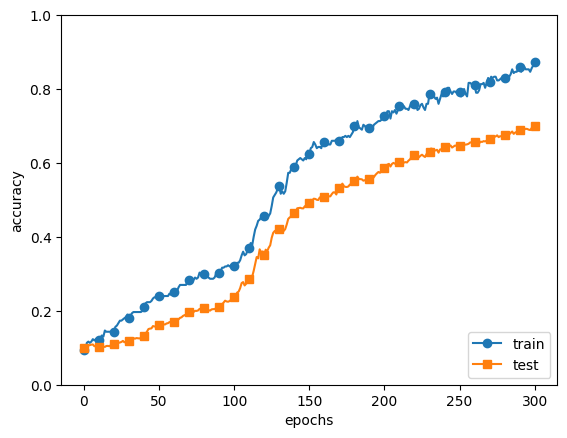

In [42]:
# Dropuoutの有無、割り合いの設定 ========================
use_dropout = True  # Dropoutなしのときの場合はFalseに
dropout_ratio = 0.15
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ratio=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

上記の結果から，Dropoutを用いることで，訓練データとテストデータの認識精度の隔たりを小さくすることができる．このように，Dropoutを用いれば表現力の高いネットワークであっても，過学習を抑制することができる．